In [1]:
import pandas as pd

prices = pd.read_csv("../data/pricecatcher_2026-09.csv")
premises = pd.read_csv("../data/lookup_premise.csv")
items = pd.read_csv("../data/lookup_item.csv")

print (prices.shape, premises.shape, items.shape)

(1390113, 4) (3916, 6) (797, 5)


In [2]:
premises.head()

,premise_code,premise,address,premise_type,state,district
0,-1,Unknown Premise,Unknown Address,NaN,NaN,NaN
1,2,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,3,JUSCO AYER KEROH,"LOT 4991,MUKIM BUKIT BARU,75450 LEBUH AYER KER...",Pasar Raya / Supermarket,Melaka,Melaka Tengah
3,6,KEDAI RUNCIT TAFAZ MAJU PRESINT 9,"NO.5, JALAN P9B/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya
4,7,KEDAI RUNCIT SYAZ MAJU PRESINT 9,"NO.5, JALAN P9E/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya


In [3]:
items.head()

,item_code,item,unit,item_group,item_category
0,-1,NaN,NaN,NaN,NaN
1,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
2,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
3,3,AYAM HIDUP,1kg,BARANGAN SEGAR,AYAM
4,9,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING


In [4]:
print(prices.columns.tolist())
print(premises.columns.tolist())
print(items.columns.tolist())

['date', 'premise_code', 'item_code', 'price']
['premise_code', 'premise', 'address', 'premise_type', 'state', 'district']
['item_code', 'item', 'unit', 'item_group', 'item_category']


In [5]:
df = prices.merge(premises, on='premise_code', how='left')
df = df.merge(items, on='item_code', how='left')

print(prices.shape, df.shape)
df.head()

(1390113, 4) (1390113, 13)


,date,premise_code,item_code,price,premise,address,premise_type,state,district,item,unit,item_group,item_category
0,2026-09-01,2,1,11.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
1,2026-09-01,2,47,10.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT
2,2026-09-01,2,55,10.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,IKAN KEMBUNG KECIL/PELALING (ANTARA 10 HINGGA ...,1kg,BARANGAN SEGAR,BAHAN LAUT
3,2026-09-01,2,70,24.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,IKAN SELAR/PELATA (≤ 7 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT
4,2026-09-01,2,88,10.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta,IKAN KELI (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,IKAN DARAT


In [6]:
df[["premise", "state", "item"]].isna().sum()

premise        0
state          0
item       19580
dtype: int64

In [7]:
missing = df[df["item"].isna()]
missing["item_code"].value_counts()

item_code
2057    2205
2094    2182
2059    2102
2095    2003
2053    1946
2089    1788
2090    1661
2091    1382
2092    1186
2023    1143
2096    1082
2093     884
2048      13
2035       3
Name: count, dtype: int64

~19.6k rows (1.4%) had item codes missing from the lookup table and were excluded.

In [8]:
df = df.dropna(subset=["item"])
print(df.shape)

(1370533, 13)


In [9]:
coverage = df.groupby("item")["state"].nunique().sort_values(ascending=False)
coverage.head(20)

item
YOGURT MARIGOLD (LOW FAT) (STRAWBERRY)         16
100 PLUS (ORIGINAL)                            16
TOMATO                                         16
TIMUN                                          16
TEPUNG NAIK SENDIRI CAP 'BLUE KEY'             16
TEPUNG GANDUM NGP (BERBUNGKUS, CAP SAUH)       16
TELUR AYAM GRED C                              16
TELUR AYAM GRED B                              16
BAYAM HIJAU                                    16
BAWANG PUTIH IMPORT (CHINA)                    16
TELUR AYAM GRED A                              16
TEH LIPTON (UNCANG)                            16
TEH BOH (UNCANG)                               16
SYAMPU SUNSILK (PELBAGAI JENIS)                16
SYAMPU REJOICE (PELBAGAI JENIS)                16
SYAMPU HEAD & SHOULDERS (SMOOTH & SILKY)       16
SUSU TEPUNG SEGERA EVERYDAY                    16
SUSU SEGAR DUTCH LADY                          16
SOTONG (ANTARA 11 HINGGA17 EKOR SEKILOGRAM)    16
SOS TOMATO MAGGI                             

In [10]:
eggs = df[df["item"] == "TELUR AYAM GRED A"]

print(eggs["unit"].unique())

by_state = (
    eggs.groupby("state")["price"]
    .agg(["median", "count"])
    .sort_values("median")
)
by_state

<StringArray>
['30 biji']
Length: 1, dtype: str


,median,count
state,,
Johor,15.20,1929
Melaka,15.29,376
W.P. Kuala Lumpur,15.30,2276
Selangor,15.30,1124
Perlis,15.40,112
W.P. Putrajaya,15.40,260
Negeri Sembilan,15.40,546
Perak,15.49,1435
Kedah,15.50,609


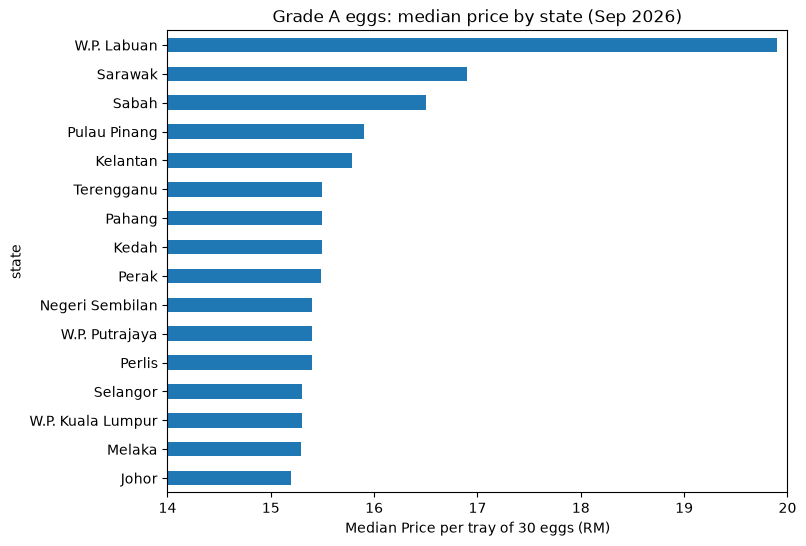

In [11]:
import matplotlib.pyplot as plt

by_state["median"].sort_values().plot(kind="barh", figsize=(8, 6))
plt.xlabel("Median Price per tray of 30 eggs (RM)")
plt.title("Grade A eggs: median price by state (Sep 2026)")
plt.xlim(14, 20)
plt.show()

In [12]:
full_items = coverage[coverage == 16].index
d = df[df["item"].isin(full_items)]

print(len(full_items), "items")
print(d.shape)

181 items
(1189907, 13)


In [13]:
item_state = d.groupby(["item", "state"])["price"].median().reset_index()
national = item_state.groupby("item")["price"].median().rename("national_median")

print(item_state.shape)
item_state.head()

(2896, 3)


,item,state,price
0,100 PLUS (ORIGINAL),Johor,3.500
1,100 PLUS (ORIGINAL),Kedah,3.545
2,100 PLUS (ORIGINAL),Kelantan,3.850
3,100 PLUS (ORIGINAL),Melaka,3.590
4,100 PLUS (ORIGINAL),Negeri Sembilan,3.225


In [14]:
national.head()

item
100 PLUS (ORIGINAL)                                                     3.59
ANMUM ESSENTIAL LANGKAH 4 PERISA ASLI (TANPA GULA TAMBAHAN) - KOTAK    37.50
ASAM JAWA (BERBIJI) PELBAGAI JENAMA                                     1.40
ASAM JAWA (TIDAK BERBIJI) ADABI                                         4.97
AYAM BERSIH - STANDARD                                                  9.29
Name: national_median, dtype: float64

In [15]:
national_df = national.reset_index()
ratios = item_state.merge(national_df, on="item", how="left")
ratios["ratio"] = ratios["price"] / ratios["national_median"]

ratios.head()

,item,state,price,national_median,ratio
0,100 PLUS (ORIGINAL),Johor,3.500,3.59,0.974930
1,100 PLUS (ORIGINAL),Kedah,3.545,3.59,0.987465
2,100 PLUS (ORIGINAL),Kelantan,3.850,3.59,1.072423
3,100 PLUS (ORIGINAL),Melaka,3.590,3.59,1.000000
4,100 PLUS (ORIGINAL),Negeri Sembilan,3.225,3.59,0.898329


In [16]:
state_index = (
    ratios.groupby("state")["ratio"]
    .mean()
    .sort_values()
)
state_index

state
Kedah                0.966179
Perak                0.971600
Melaka               0.975425
Negeri Sembilan      0.976001
Pahang               0.987026
Pulau Pinang         0.988175
Johor                0.989133
Selangor             0.993306
Kelantan             1.009361
Terengganu           1.009891
Perlis               1.021571
W.P. Kuala Lumpur    1.063040
W.P. Putrajaya       1.070414
Sabah                1.086175
Sarawak              1.093158
W.P. Labuan          1.125582
Name: ratio, dtype: float64

In [17]:
sample = d.groupby("state").agg(
    rows=("price", "count"),
    premises=("premise_code", "nunique"),
)
sample.sort_values("rows")

,rows,premises
state,,
W.P. Labuan,7674,15
Perlis,16917,37
W.P. Putrajaya,18158,28
Melaka,28533,53
Negeri Sembilan,40096,64
Terengganu,66890,139
Kedah,68820,122
Sabah,78292,191
Pulau Pinang,83656,147


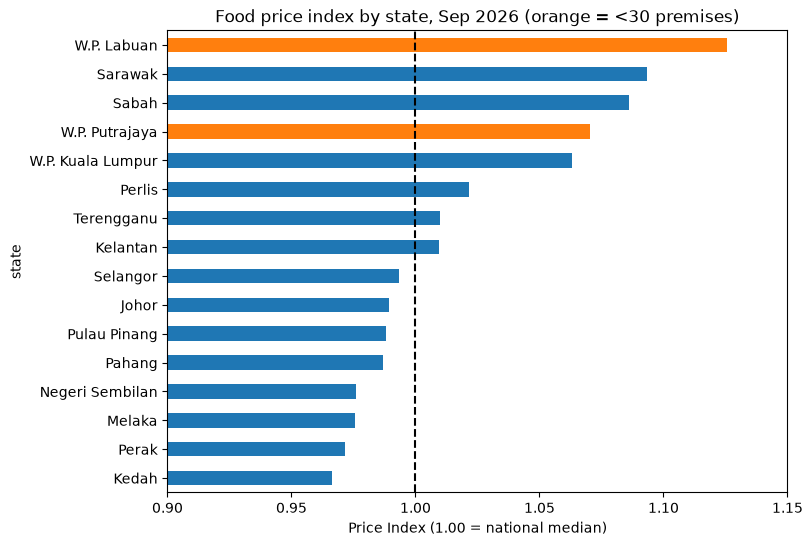

In [18]:
low = sample[sample["premises"] < 30].index
colors = ["tab:orange" if s in low else "tab:blue" for s in state_index.index]

state_index.plot(kind="barh", figsize=(8, 6), color=colors)
plt.axvline(1.0, color="black", linestyle="--")
plt.xlim(0.9, 1.15)
plt.xlabel("Price Index (1.00 = national median)")
plt.title("Food price index by state, Sep 2026 (orange = <30 premises)")
plt.savefig("../figures/state_price_index.png", dpi=150, bbox_inches="tight")
plt.show()